# 🌀 Mecánica Variacional: Curso Riguroso Paso a Paso

---

## Tabla de Contenidos

1. **Introducción y Motivación**
2. **Fundamentos del Cálculo Variacional**
   - Funcionales
   - Ecuación de Euler-Lagrange
3. **Problema de la Braquistócrona**
4. **Mecánica Lagrangiana**
   - Principio de Hamilton
   - Coordenadas generalizadas
5. **Aplicaciones Clásicas**
   - Péndulo simple
   - Oscilador armónico
   - Péndulo doble (caos)
6. **Mecánica Hamiltoniana**
   - Transformación de Legendre
   - Ecuaciones de Hamilton
   - Espacio de fases
7. **Teorema de Noether y Simetrías**
8. **Ejercicios Propuestos**

---

**Prerequisitos:** Cálculo multivariable, ecuaciones diferenciales ordinarias, mecánica newtoniana básica.

**Herramientas:** `numpy`, `scipy`, `matplotlib`, `seaborn`, `sympy`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.integrate import solve_ivp, quad
from scipy.optimize import minimize
import sympy as sp
from sympy import symbols, Function, diff, simplify, cos, sin, sqrt, pi, Rational
from sympy import latex, Eq, solve as sp_solve
from IPython.display import display, Math, Markdown
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'text.usetex': False,
})

print("✅ Todas las librerías cargadas correctamente.")

✅ Todas las librerías cargadas correctamente.


---

## 1. Introducción y Motivación

### ¿Por qué mecánica variacional?

La mecánica newtoniana se basa en **fuerzas y aceleraciones** ($\vec{F} = m\vec{a}$). Esto funciona bien para problemas simples, pero tiene limitaciones:

- Requiere descomponer fuerzas en cada dirección
- Las restricciones (cuerdas, superficies, rieles) son difíciles de manejar
- No se generaliza fácilmente a otros campos de la física

La **mecánica variacional** reformula toda la mecánica a partir de un **principio único**: la naturaleza elige el camino que hace **estacionaria** cierta cantidad llamada **acción**.

$$S[q] = \int_{t_1}^{t_2} L(q, \dot{q}, t) \, dt$$

donde $L = T - V$ es el **Lagrangiano** (energía cinética menos potencial).

> **Idea central:** En lugar de preguntarnos "¿qué fuerza actúa en cada instante?", preguntamos "¿qué trayectoria entre A y B hace que la acción sea estacionaria?"

### Analogía geométrica

Así como una línea recta minimiza la distancia entre dos puntos en el espacio plano, las trayectorias físicas **extremizan la acción** en el "espacio de caminos".

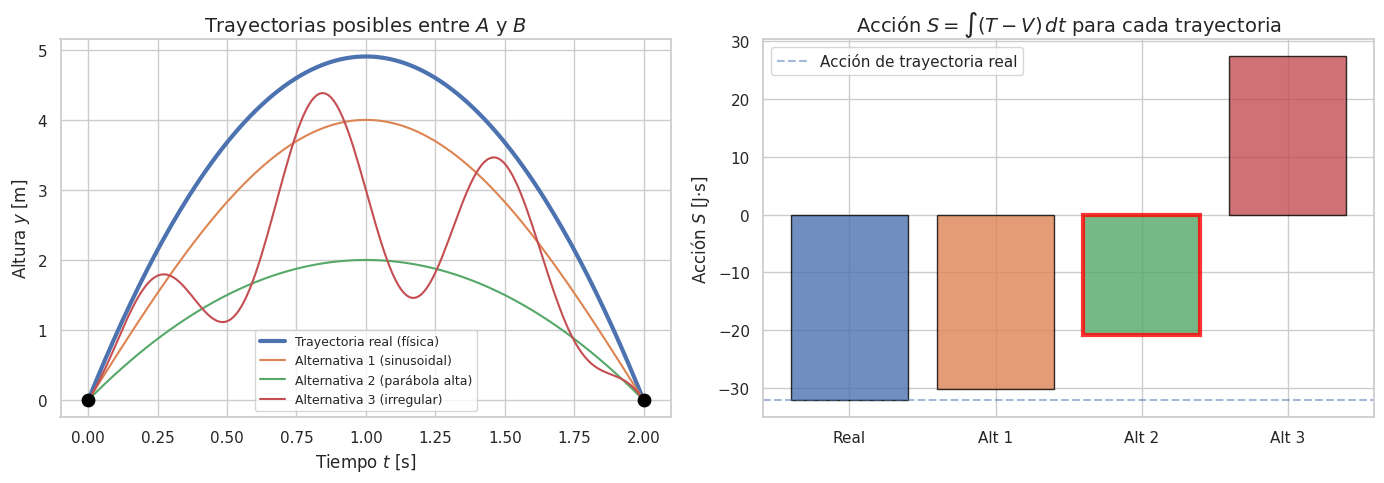


📊 Valores de la acción S:
   Trayectoria real (física): S = -32.080 J·s
   Alternativa 1 (sinusoidal): S = -30.223 J·s
   Alternativa 2 (parábola alta): S = -20.827 J·s
   Alternativa 3 (irregular): S = 27.364 J·s


In [2]:
# Visualización: Comparación de caminos y la idea de acción mínima
# Mostramos varias trayectorias posibles entre dos puntos y calculamos la acción para cada una

g = 9.81  # gravedad
m = 1.0   # masa

t = np.linspace(0, 2, 200)
t1, t2 = 0, 2
y1, y2 = 0, 0  # caída libre: sube y baja

# Trayectoria real (parábola): y(t) = v0*t - 0.5*g*t^2, con y(2)=0 => v0 = g
v0 = g * (t2 - t1) / 2
y_real = v0 * t - 0.5 * g * t**2

# Trayectorias alternativas (no físicas)
y_alt1 = 4 * np.sin(np.pi * t / 2)           # sinusoidal
y_alt2 = 8 * t * (2 - t) / 4                  # parábola más alta  
y_alt3 = 3 * t * (2 - t) * (1 + 0.5*np.sin(3*np.pi*t))  # irregular

trajectories = [
    (y_real, "Trayectoria real (física)", "C0", 3),
    (y_alt1, "Alternativa 1 (sinusoidal)", "C1", 1.5),
    (y_alt2, "Alternativa 2 (parábola alta)", "C2", 1.5),
    (y_alt3, "Alternativa 3 (irregular)", "C3", 1.5),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: trayectorias
ax = axes[0]
for y_traj, label, color, lw in trajectories:
    ax.plot(t, y_traj, label=label, color=color, linewidth=lw)
ax.set_xlabel("Tiempo $t$ [s]")
ax.set_ylabel("Altura $y$ [m]")
ax.set_title("Trayectorias posibles entre $A$ y $B$")
ax.legend(fontsize=9)
ax.scatter([0, 2], [0, 0], color='black', zorder=5, s=80, label='Puntos fijos')

# Panel derecho: acción para cada trayectoria
actions = []
for y_traj, label, color, lw in trajectories:
    dt = t[1] - t[0]
    y_dot = np.gradient(y_traj, dt)
    T = 0.5 * m * y_dot**2           # energía cinética
    V = m * g * y_traj               # energía potencial
    L = T - V                        # lagrangiano
    action = np.trapezoid(L, t)
    actions.append(action)

ax2 = axes[1]
labels_short = ["Real", "Alt 1", "Alt 2", "Alt 3"]
colors = ["C0", "C1", "C2", "C3"]
bars = ax2.bar(labels_short, actions, color=colors, edgecolor='black', alpha=0.8)
ax2.set_ylabel("Acción $S$ [J·s]")
ax2.set_title("Acción $S = \\int (T - V) \\, dt$ para cada trayectoria")
ax2.axhline(y=actions[0], color='C0', linestyle='--', alpha=0.5, label='Acción de trayectoria real')
ax2.legend()

# Marcar la acción mínima
min_idx = np.argmin(np.abs(actions))
bars[min_idx].set_edgecolor('red')
bars[min_idx].set_linewidth(3)

plt.tight_layout()
plt.show()

print(f"\n📊 Valores de la acción S:")
for (_, label, _, _), S in zip(trajectories, actions):
    print(f"   {label}: S = {S:.3f} J·s")

---

## 2. Fundamentos del Cálculo Variacional

### 2.1 Funcionales

Un **funcional** es una función que toma una función entera como argumento y devuelve un número. Notación: $J[y]$.

**Ejemplos de funcionales:**

| Funcional | Expresión | Significado |
|-----------|-----------|-------------|
| Longitud de arco | $L[y] = \int_a^b \sqrt{1 + (y')^2} \, dx$ | Longitud de la curva $y(x)$ |
| Acción mecánica | $S[q] = \int_{t_1}^{t_2} L(q, \dot{q}, t) \, dt$ | Acción a lo largo de la trayectoria |
| Área de superficie | $A[y] = 2\pi \int_a^b y \sqrt{1 + (y')^2} \, dx$ | Superficie de revolución |

### 2.2 Variación de un funcional

La **variación** $\delta y(x)$ es una perturbación infinitesimal de la función $y(x)$:

$$y(x) \to y(x) + \epsilon \, \eta(x), \quad \eta(a) = \eta(b) = 0$$

donde $\eta(x)$ es una función arbitraria que se anula en los extremos.

### 2.3 Ecuación de Euler-Lagrange

Para que el funcional 

$$J[y] = \int_a^b F(x, y, y') \, dx$$

sea estacionario ($\delta J = 0$), la función $y(x)$ debe satisfacer la **ecuación de Euler-Lagrange**:

$$\boxed{\frac{\partial F}{\partial y} - \frac{d}{dx}\frac{\partial F}{\partial y'} = 0}$$

**Demostración esquemática:**

1. Sustituir $y + \epsilon\eta$ en $J$
2. Derivar respecto a $\epsilon$ y evaluar en $\epsilon = 0$
3. Integrar por partes el término con $\eta'$
4. Usar que $\eta$ es arbitraria (lema fundamental del cálculo variacional)

In [3]:
# Derivación simbólica de la ecuación de Euler-Lagrange con SymPy

x = symbols('x')
y = Function('y')
F = Function('F')

# La ecuación de Euler-Lagrange en forma general
y_func = y(x)
y_prime = diff(y_func, x)

print("═" * 60)
print("  DERIVACIÓN DE LA ECUACIÓN DE EULER-LAGRANGE")
print("═" * 60)

display(Markdown(r"""
**Paso 1:** Consideramos el funcional $J[y] = \int_a^b F(x, y, y') \, dx$

**Paso 2:** Perturbamos: $y(x) \to y(x) + \epsilon \eta(x)$

$$J[y + \epsilon\eta] = \int_a^b F(x, y + \epsilon\eta, y' + \epsilon\eta') \, dx$$

**Paso 3:** Derivamos respecto a $\epsilon$ y evaluamos en $\epsilon = 0$:

$$\frac{dJ}{d\epsilon}\bigg|_{\epsilon=0} = \int_a^b \left[\frac{\partial F}{\partial y}\eta + \frac{\partial F}{\partial y'}\eta'\right] dx = 0$$

**Paso 4:** Integramos por partes el segundo término:

$$\int_a^b \frac{\partial F}{\partial y'}\eta' \, dx = \underbrace{\left[\frac{\partial F}{\partial y'}\eta\right]_a^b}_{= 0} - \int_a^b \frac{d}{dx}\frac{\partial F}{\partial y'}\eta \, dx$$

**Paso 5:** Combinamos y usamos que $\eta$ es arbitraria:

$$\int_a^b \left[\frac{\partial F}{\partial y} - \frac{d}{dx}\frac{\partial F}{\partial y'}\right]\eta \, dx = 0 \implies \boxed{\frac{\partial F}{\partial y} - \frac{d}{dx}\frac{\partial F}{\partial y'} = 0}$$
"""))

# Ejemplo: Geodésica en el plano (distancia mínima)
print("\n" + "═" * 60)
print("  EJEMPLO: Geodésica en el plano")
print("═" * 60)
print("\nFuncional de longitud de arco: J[y] = ∫ √(1 + y'²) dx")
print("Aquí F(x, y, y') = √(1 + y'²)")

yp = symbols("y'", real=True)
F_geo = sqrt(1 + yp**2)

dF_dy = diff(F_geo, symbols('y'))
dF_dyp = diff(F_geo, yp)

print(f"\n∂F/∂y = {dF_dy}")
print(f"∂F/∂y' = {dF_dyp}")
print(f"\nd/dx(∂F/∂y') = 0  (pues ∂F/∂y' solo depende de y')")
print(f"\nEcuación de E-L: 0 - d/dx[{dF_dyp}] = 0")
print(f"⟹ y'' = 0  ⟹  y = ax + b  (¡Línea recta!)")
print("\n✅ La geodésica en el plano es efectivamente una línea recta.")

════════════════════════════════════════════════════════════
  DERIVACIÓN DE LA ECUACIÓN DE EULER-LAGRANGE
════════════════════════════════════════════════════════════



**Paso 1:** Consideramos el funcional $J[y] = \int_a^b F(x, y, y') \, dx$

**Paso 2:** Perturbamos: $y(x) \to y(x) + \epsilon \eta(x)$

$$J[y + \epsilon\eta] = \int_a^b F(x, y + \epsilon\eta, y' + \epsilon\eta') \, dx$$

**Paso 3:** Derivamos respecto a $\epsilon$ y evaluamos en $\epsilon = 0$:

$$\frac{dJ}{d\epsilon}\bigg|_{\epsilon=0} = \int_a^b \left[\frac{\partial F}{\partial y}\eta + \frac{\partial F}{\partial y'}\eta'\right] dx = 0$$

**Paso 4:** Integramos por partes el segundo término:

$$\int_a^b \frac{\partial F}{\partial y'}\eta' \, dx = \underbrace{\left[\frac{\partial F}{\partial y'}\eta\right]_a^b}_{= 0} - \int_a^b \frac{d}{dx}\frac{\partial F}{\partial y'}\eta \, dx$$

**Paso 5:** Combinamos y usamos que $\eta$ es arbitraria:

$$\int_a^b \left[\frac{\partial F}{\partial y} - \frac{d}{dx}\frac{\partial F}{\partial y'}\right]\eta \, dx = 0 \implies \boxed{\frac{\partial F}{\partial y} - \frac{d}{dx}\frac{\partial F}{\partial y'} = 0}$$



════════════════════════════════════════════════════════════
  EJEMPLO: Geodésica en el plano
════════════════════════════════════════════════════════════

Funcional de longitud de arco: J[y] = ∫ √(1 + y'²) dx
Aquí F(x, y, y') = √(1 + y'²)

∂F/∂y = 0
∂F/∂y' = y'/sqrt(y'**2 + 1)

d/dx(∂F/∂y') = 0  (pues ∂F/∂y' solo depende de y')

Ecuación de E-L: 0 - d/dx[y'/sqrt(y'**2 + 1)] = 0
⟹ y'' = 0  ⟹  y = ax + b  (¡Línea recta!)

✅ La geodésica en el plano es efectivamente una línea recta.


📏 Longitudes de arco:
   Geodésica (línea recta): L = 5.8310
   Curva perturbada 1: L = 6.5369
   Curva perturbada 2: L = 7.0647
   Curva perturbada 3: L = 7.5650


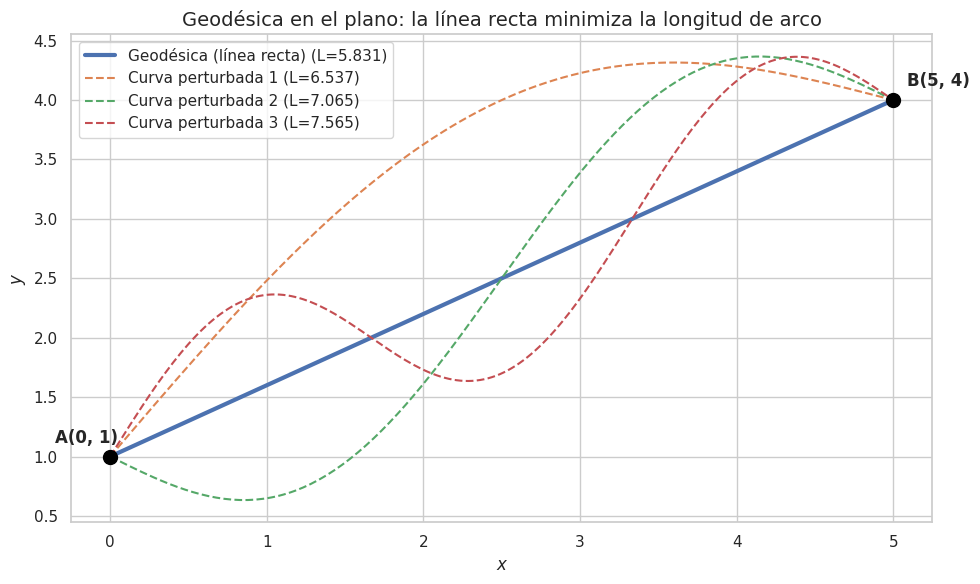

In [4]:
# Visualización: Geodésicas en el plano vs curvas arbitrarias

fig, ax = plt.subplots(figsize=(10, 6))

x_vals = np.linspace(0, 5, 200)
# Línea recta (geodésica): pasa por (0,1) y (5,4)
y_geodesica = 1 + 0.6 * x_vals

# Curvas no-geodésicas
y_curva1 = 1 + 0.6 * x_vals + 1.5 * np.sin(np.pi * x_vals / 5)
y_curva2 = 1 + 0.6 * x_vals - 1.0 * np.sin(2 * np.pi * x_vals / 5)
y_curva3 = 1 + 0.6 * x_vals + 0.8 * np.sin(3 * np.pi * x_vals / 5)

curves = [
    (y_geodesica, "Geodésica (línea recta)", "C0", 3, '-'),
    (y_curva1, "Curva perturbada 1", "C1", 1.5, '--'),
    (y_curva2, "Curva perturbada 2", "C2", 1.5, '--'),
    (y_curva3, "Curva perturbada 3", "C3", 1.5, '--'),
]

# Calcular longitudes de arco
print("📏 Longitudes de arco:")
for y_c, label, color, lw, ls in curves:
    dx = x_vals[1] - x_vals[0]
    dy = np.gradient(y_c, dx)
    arc_length = np.trapezoid(np.sqrt(1 + dy**2), x_vals)
    ax.plot(x_vals, y_c, color=color, linewidth=lw, linestyle=ls, label=f"{label} (L={arc_length:.3f})")
    print(f"   {label}: L = {arc_length:.4f}")

ax.scatter([0, 5], [1, 4], color='black', s=100, zorder=5)
ax.annotate('A(0, 1)', (0, 1), textcoords="offset points", xytext=(-40, 10), fontsize=12, fontweight='bold')
ax.annotate('B(5, 4)', (5, 4), textcoords="offset points", xytext=(10, 10), fontsize=12, fontweight='bold')

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Geodésica en el plano: la línea recta minimiza la longitud de arco")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

---

## 3. El Problema de la Braquistócrona

### El problema histórico más famoso del cálculo variacional

> **Enunciado (Johann Bernoulli, 1696):** ¿Cuál es la curva que conecta dos puntos $A$ y $B$ tal que una partícula deslizándose bajo gravedad (sin fricción) recorre la distancia en el **menor tiempo posible**?

### Planteamiento matemático

Usando conservación de energía: $v = \sqrt{2gy}$ (tomando $y$ positivo hacia abajo).

El tiempo de descenso es:

$$T[y] = \int_0^{x_B} \frac{\sqrt{1 + (y')^2}}{\sqrt{2gy}} \, dx$$

Aquí el integrando es:

$$F(y, y') = \frac{\sqrt{1 + (y')^2}}{\sqrt{2gy}}$$

### Solución: La cicloide

Aplicando la ecuación de Euler-Lagrange (usando la identidad de Beltrami, ya que $F$ no depende explícitamente de $x$):

$$F - y' \frac{\partial F}{\partial y'} = C$$

Se obtiene la **cicloide**:

$$\begin{cases} x(\theta) = R(\theta - \sin\theta) \\ y(\theta) = R(1 - \cos\theta) \end{cases}$$

donde $R$ es el radio del círculo generador.

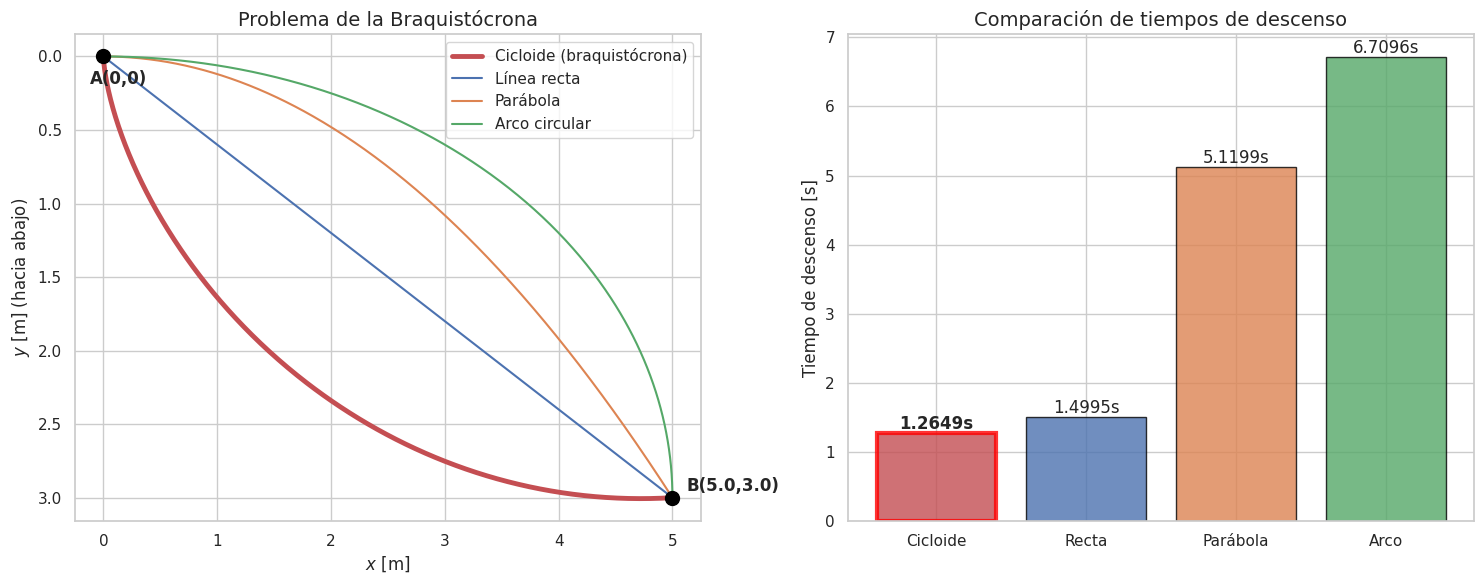


🏆 La cicloide es la curva de descenso más rápido!
   Tiempo cicloide: 1.2649 s
   Mejora vs línea recta: 15.6%


In [5]:
# La Braquistócrona: Comparación de curvas y tiempos de descenso

def cycloid(R, theta_max, n_points=500):
    """Genera una cicloide parametrizada."""
    theta = np.linspace(0, theta_max, n_points)
    x = R * (theta - np.sin(theta))
    y = R * (1 - np.cos(theta))
    return x, y

def descent_time(x_path, y_path, g=9.81):
    """Calcula el tiempo de descenso por una curva bajo gravedad."""
    T = 0
    for i in range(1, len(x_path)):
        dx = x_path[i] - x_path[i-1]
        dy = y_path[i] - y_path[i-1]
        ds = np.sqrt(dx**2 + dy**2)
        y_avg = 0.5 * (y_path[i] + y_path[i-1])
        if y_avg > 1e-10:
            v = np.sqrt(2 * g * y_avg)
            T += ds / v
    return T

# Punto final
xB, yB = 5.0, 3.0

# 1. Cicloide (braquistócrona) - encontrar R y theta_max
from scipy.optimize import fsolve

def cycloid_endpoint(params):
    R, theta_max = params
    x_end = R * (theta_max - np.sin(theta_max))
    y_end = R * (1 - np.cos(theta_max))
    return [x_end - xB, y_end - yB]

R_sol, theta_sol = fsolve(cycloid_endpoint, [2.0, 2.5])
x_cycl, y_cycl = cycloid(R_sol, theta_sol)

# 2. Línea recta
x_line = np.linspace(0, xB, 500)
y_line = (yB / xB) * x_line

# 3. Parábola
x_par = np.linspace(0, xB, 500)
y_par = yB * (x_par / xB)**2

# 4. Cuarto de círculo
theta_circ = np.linspace(0, np.pi/2, 500)
# Ajustar para pasar por (0,0) y (xB, yB)
x_circ = xB * np.sin(theta_circ)
y_circ = yB * (1 - np.cos(theta_circ))

curves_brach = [
    (x_cycl, y_cycl, "Cicloide (braquistócrona)", "C3", 3.5),
    (x_line, y_line, "Línea recta", "C0", 1.5),
    (x_par, y_par, "Parábola", "C1", 1.5),
    (x_circ, y_circ, "Arco circular", "C2", 1.5),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: curvas
ax1 = axes[0]
times = []
for xc, yc, label, color, lw in curves_brach:
    T = descent_time(xc, yc)
    times.append(T)
    ax1.plot(xc, yc, color=color, linewidth=lw, label=f"{label}")
    
ax1.scatter([0, xB], [0, yB], color='black', s=100, zorder=5)
ax1.annotate('A(0,0)', (0, 0), xytext=(-10, -20), textcoords='offset points', fontsize=12, fontweight='bold')
ax1.annotate(f'B({xB},{yB})', (xB, yB), xytext=(10, 5), textcoords='offset points', fontsize=12, fontweight='bold')
ax1.set_xlabel("$x$ [m]")
ax1.set_ylabel("$y$ [m] (hacia abajo)")
ax1.set_title("Problema de la Braquistócrona")
ax1.legend()
ax1.invert_yaxis()

# Panel derecho: tiempos
ax2 = axes[1]
labels_b = ["Cicloide", "Recta", "Parábola", "Arco"]
colors_b = ["C3", "C0", "C1", "C2"]
bars = ax2.bar(labels_b, times, color=colors_b, edgecolor='black', alpha=0.8)
ax2.set_ylabel("Tiempo de descenso [s]")
ax2.set_title("Comparación de tiempos de descenso")

# Marcar el mínimo
min_idx = np.argmin(times)
bars[min_idx].set_edgecolor('red')
bars[min_idx].set_linewidth(3)

for i, (bar, t_val) in enumerate(zip(bars, times)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{t_val:.4f}s', ha='center', va='bottom', fontweight='bold' if i == min_idx else 'normal')

plt.tight_layout()
plt.show()

print(f"\n🏆 La cicloide es la curva de descenso más rápido!")
print(f"   Tiempo cicloide: {times[0]:.4f} s")
print(f"   Mejora vs línea recta: {(times[1]-times[0])/times[1]*100:.1f}%")

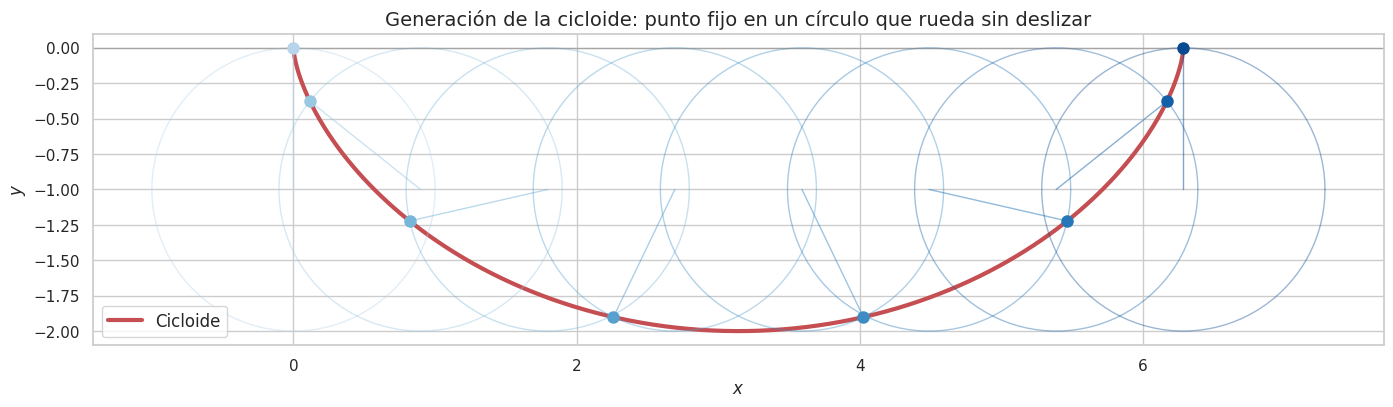

In [6]:
# Visualización 3D: La cicloide como curva generada por un punto en un círculo rodante

fig = plt.figure(figsize=(14, 5))

# Animación estática de la generación de la cicloide
ax = fig.add_subplot(111)

R_vis = 1.0
n_frames = 8
theta_full = np.linspace(0, 2*np.pi, 300)

# Dibujar la cicloide completa
x_full = R_vis * (theta_full - np.sin(theta_full))
y_full = R_vis * (1 - np.cos(theta_full))
ax.plot(x_full, -y_full, 'C3', linewidth=3, label='Cicloide', zorder=2)

# Dibujar posiciones del círculo
colors_gen = plt.cm.Blues(np.linspace(0.3, 0.9, n_frames))
for i, theta_pos in enumerate(np.linspace(0, 2*np.pi, n_frames)):
    # Centro del círculo
    cx = R_vis * theta_pos
    cy = R_vis
    
    # Dibujar el círculo
    circle_x = cx + R_vis * np.cos(np.linspace(0, 2*np.pi, 100))
    circle_y = -(cy + R_vis * np.sin(np.linspace(0, 2*np.pi, 100)))
    ax.plot(circle_x, circle_y, color=colors_gen[i], alpha=0.4, linewidth=1)
    
    # Punto generador
    px = R_vis * (theta_pos - np.sin(theta_pos))
    py = -(R_vis * (1 - np.cos(theta_pos)))
    ax.plot(px, py, 'o', color=colors_gen[i], markersize=8, zorder=5)
    
    # Radio al punto generador
    ax.plot([cx, px], [-cy, py], color=colors_gen[i], alpha=0.5, linewidth=1)

# Línea base
ax.axhline(y=0, color='gray', linewidth=1, linestyle='-', alpha=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Generación de la cicloide: punto fijo en un círculo que rueda sin deslizar")
ax.set_aspect('equal')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. Mecánica Lagrangiana

### 4.1 Principio de Hamilton (Principio de Mínima Acción)

> **Principio de Hamilton:** De todas las trayectorias posibles $q(t)$ que conectan la configuración $q(t_1)$ con $q(t_2)$, la trayectoria física es aquella que hace **estacionaria** la acción:
>
> $$\delta S = \delta \int_{t_1}^{t_2} L(q, \dot{q}, t) \, dt = 0$$

### 4.2 El Lagrangiano

$$L(q, \dot{q}, t) = T(\dot{q}) - V(q)$$

- $T$: energía cinética
- $V$: energía potencial
- $q$: coordenadas generalizadas (pueden ser ángulos, distancias, etc.)

### 4.3 Ecuaciones de Euler-Lagrange para mecánica

Para cada coordenada generalizada $q_i$:

$$\boxed{\frac{d}{dt}\frac{\partial L}{\partial \dot{q}_i} - \frac{\partial L}{\partial q_i} = 0}$$

**Ventajas sobre Newton:**
- No necesitamos fuerzas de restricción
- Funciona en cualquier sistema de coordenadas
- Se extiende naturalmente a campos y relatividad

### 4.4 Coordenadas generalizadas

| Sistema | Coord. cartesianas | Coord. generalizadas |
|---------|-------------------|---------------------|
| Péndulo simple | $(x, y)$ con restricción | $\theta$ (1 DOF) |
| Péndulo doble | $(x_1,y_1,x_2,y_2)$ con 2 restr. | $(\theta_1, \theta_2)$ (2 DOF) |
| Partícula en esfera | $(x,y,z)$ con restricción | $(\theta, \phi)$ (2 DOF) |

---

## 5. Aplicaciones Clásicas

### 5.1 Péndulo Simple

In [7]:
# ═══════════════════════════════════════════════════
# PÉNDULO SIMPLE: Derivación simbólica con SymPy
# ═══════════════════════════════════════════════════

t_sym = symbols('t')
theta_sym = Function('theta')
m_sym, l_sym, g_sym = symbols('m l g', positive=True)

theta_t = theta_sym(t_sym)
theta_dot = diff(theta_t, t_sym)

# Coordenadas cartesianas en términos de theta
x_pend = l_sym * sin(theta_t)
y_pend = -l_sym * cos(theta_t)

# Velocidades
vx = diff(x_pend, t_sym)
vy = diff(y_pend, t_sym)

# Energía cinética
T_pend = Rational(1, 2) * m_sym * (vx**2 + vy**2)
T_pend = simplify(T_pend)

# Energía potencial
V_pend = m_sym * g_sym * y_pend

# Lagrangiano
L_pend = simplify(T_pend - V_pend)

print("═" * 60)
print("  PÉNDULO SIMPLE - Formulación Lagrangiana")
print("═" * 60)
print(f"\nCoordenada generalizada: θ(t)")
print(f"\nx = l·sin(θ),  y = -l·cos(θ)")
display(Math(r"T = " + latex(T_pend)))
display(Math(r"V = " + latex(V_pend)))
display(Math(r"L = T - V = " + latex(L_pend)))

# Ecuación de Euler-Lagrange
dL_dtheta = diff(L_pend, theta_t)
dL_dthetadot = diff(L_pend, theta_dot)
EL = simplify(diff(dL_dthetadot, t_sym) - dL_dtheta)

print("\nEcuación de Euler-Lagrange:")
display(Math(r"\frac{d}{dt}\frac{\partial L}{\partial \dot{\theta}} - \frac{\partial L}{\partial \theta} = 0"))
display(Math(latex(Eq(EL, 0))))

# Simplificar
EL_simple = simplify(EL / (m_sym * l_sym**2))
print("\nDividiendo por ml²:")
display(Math(latex(Eq(EL_simple, 0))))
print("\n✅ Resultado: θ̈ + (g/l)sin(θ) = 0  (Ecuación del péndulo no lineal)")

════════════════════════════════════════════════════════════
  PÉNDULO SIMPLE - Formulación Lagrangiana
════════════════════════════════════════════════════════════

Coordenada generalizada: θ(t)

x = l·sin(θ),  y = -l·cos(θ)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Ecuación de Euler-Lagrange:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Dividiendo por ml²:


<IPython.core.display.Math object>


✅ Resultado: θ̈ + (g/l)sin(θ) = 0  (Ecuación del péndulo no lineal)


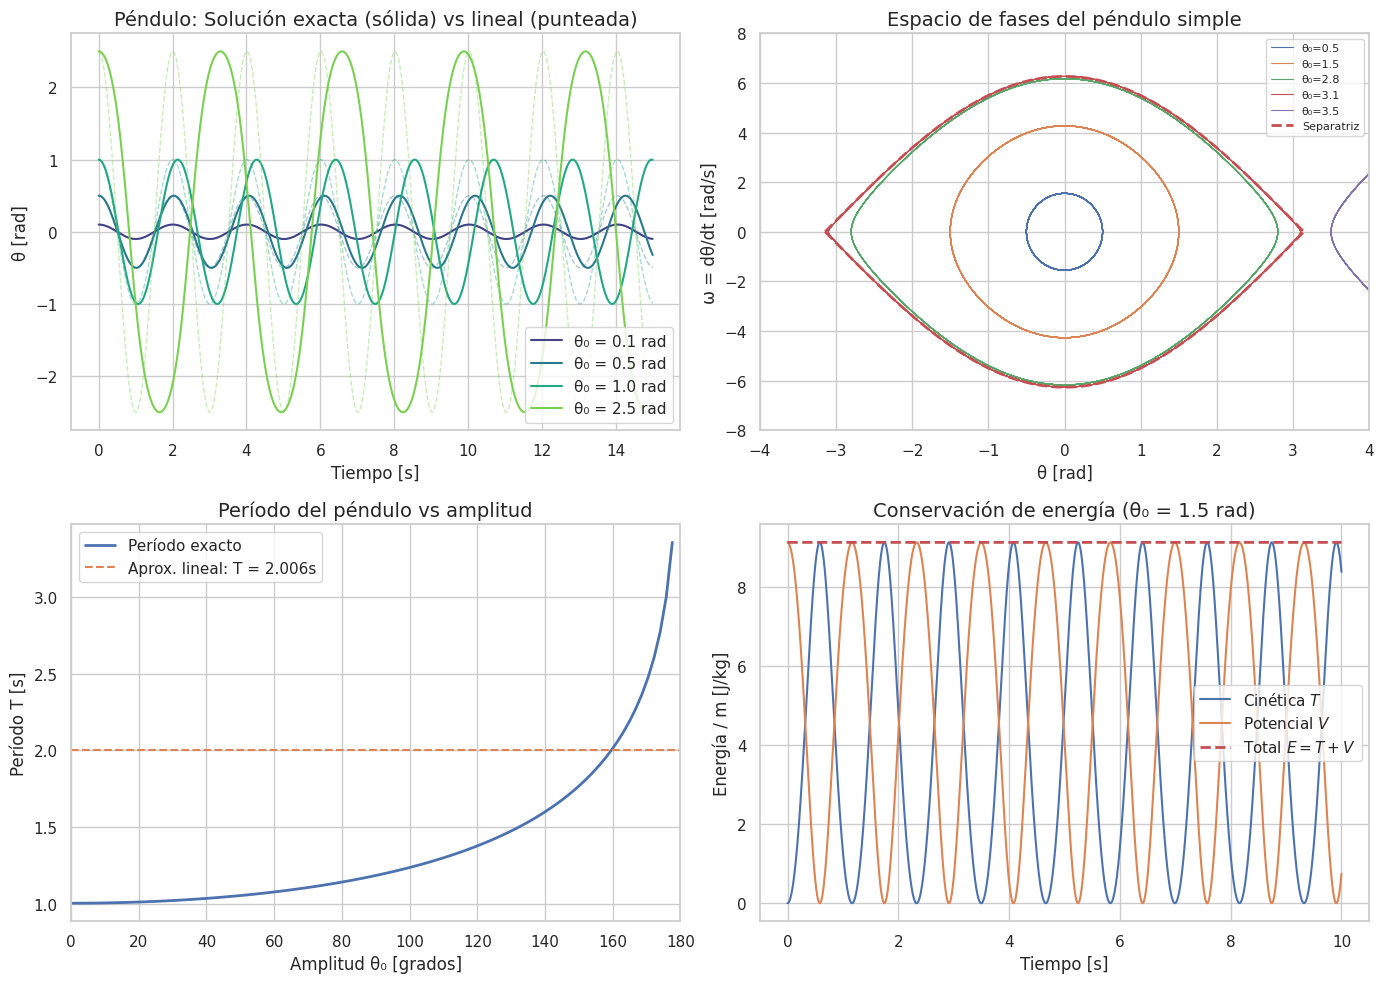

In [8]:
# Solución numérica del péndulo simple: lineal vs no lineal

def pendulum_ode(t, state, g, l):
    """EDO del péndulo: θ'' + (g/l)sin(θ) = 0"""
    theta, omega = state
    return [omega, -(g/l) * np.sin(theta)]

g_val, l_val = 9.81, 1.0
t_span = (0, 15)
t_eval = np.linspace(*t_span, 2000)

# Diferentes amplitudes iniciales
theta0_list = [0.1, 0.5, 1.0, 2.5]
colors_pend = sns.color_palette("viridis", len(theta0_list))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: θ(t) para diferentes amplitudes
ax1 = axes[0, 0]
for theta0, color in zip(theta0_list, colors_pend):
    sol = solve_ivp(pendulum_ode, t_span, [theta0, 0], args=(g_val, l_val), 
                    t_eval=t_eval, method='RK45', rtol=1e-10)
    ax1.plot(sol.t, sol.y[0], color=color, linewidth=1.5, label=f"θ₀ = {theta0:.1f} rad")
    
    # Solución linealizada
    omega_n = np.sqrt(g_val / l_val)
    theta_lin = theta0 * np.cos(omega_n * t_eval)
    ax1.plot(t_eval, theta_lin, '--', color=color, alpha=0.4, linewidth=1)

ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("θ [rad]")
ax1.set_title("Péndulo: Solución exacta (sólida) vs lineal (punteada)")
ax1.legend()

# Panel 2: Espacio de fases
ax2 = axes[0, 1]
theta0_phase = [0.5, 1.5, 2.8, 3.1, 3.5]
for theta0 in theta0_phase:
    sol = solve_ivp(pendulum_ode, (0, 30), [theta0, 0], args=(g_val, l_val),
                    t_eval=np.linspace(0, 30, 5000), method='RK45', rtol=1e-10)
    ax2.plot(sol.y[0], sol.y[1], linewidth=0.8, label=f"θ₀={theta0:.1f}")

# Separatriz
theta_sep = np.linspace(-np.pi, np.pi, 500)
omega_sep_pos = np.sqrt(2 * g_val / l_val * (1 + np.cos(theta_sep)))
omega_sep_neg = -omega_sep_pos
ax2.plot(theta_sep, omega_sep_pos, 'r--', linewidth=2, label='Separatriz')
ax2.plot(theta_sep, omega_sep_neg, 'r--', linewidth=2)

ax2.set_xlabel("θ [rad]")
ax2.set_ylabel("ω = dθ/dt [rad/s]")
ax2.set_title("Espacio de fases del péndulo simple")
ax2.legend(fontsize=8)
ax2.set_xlim(-4, 4)
ax2.set_ylim(-8, 8)

# Panel 3: Período vs amplitud (no linealidad)
ax3 = axes[1, 0]
theta0_range = np.linspace(0.01, 3.1, 100)
periods = []
T_linear = 2 * np.pi * np.sqrt(l_val / g_val)

for theta0 in theta0_range:
    sol = solve_ivp(pendulum_ode, (0, 20), [theta0, 0], args=(g_val, l_val),
                    t_eval=np.linspace(0, 20, 10000), method='RK45', rtol=1e-12)
    # Encontrar primer cruce por cero descendente
    theta_sol = sol.y[0]
    crossings = np.where(np.diff(np.sign(theta_sol)) < 0)[0]
    if len(crossings) >= 1:
        # Interpolación para mejor precisión
        idx = crossings[0]
        t1 = sol.t[idx]
        t2 = sol.t[idx + 1]
        y1 = theta_sol[idx]
        y2 = theta_sol[idx + 1]
        t_cross = t1 - y1 * (t2 - t1) / (y2 - y1)
        periods.append(2 * t_cross)
    else:
        periods.append(np.nan)

ax3.plot(np.degrees(theta0_range), periods, 'C0', linewidth=2, label='Período exacto')
ax3.axhline(y=T_linear, color='C1', linestyle='--', linewidth=1.5, label=f'Aprox. lineal: T = {T_linear:.3f}s')
ax3.set_xlabel("Amplitud θ₀ [grados]")
ax3.set_ylabel("Período T [s]")
ax3.set_title("Período del péndulo vs amplitud")
ax3.legend()
ax3.set_xlim(0, 180)

# Panel 4: Energía (conservación)
ax4 = axes[1, 1]
theta0_e = 1.5
sol_e = solve_ivp(pendulum_ode, (0, 10), [theta0_e, 0], args=(g_val, l_val),
                  t_eval=np.linspace(0, 10, 2000), method='RK45', rtol=1e-12)
T_kin = 0.5 * l_val**2 * sol_e.y[1]**2
V_pot = g_val * l_val * (1 - np.cos(sol_e.y[0]))
E_total = T_kin + V_pot

ax4.plot(sol_e.t, T_kin, label='Cinética $T$', color='C0')
ax4.plot(sol_e.t, V_pot, label='Potencial $V$', color='C1')
ax4.plot(sol_e.t, E_total, label='Total $E = T + V$', color='C3', linewidth=2, linestyle='--')
ax4.set_xlabel("Tiempo [s]")
ax4.set_ylabel("Energía / m [J/kg]")
ax4.set_title(f"Conservación de energía (θ₀ = {theta0_e} rad)")
ax4.legend()

plt.tight_layout()
plt.show()

### 5.2 Oscilador Armónico

El sistema más fundamental de la física. Lagrangiano:

$$L = \frac{1}{2}m\dot{x}^2 - \frac{1}{2}k x^2$$

La ecuación de Euler-Lagrange da directamente: $m\ddot{x} + kx = 0$, con solución $x(t) = A\cos(\omega t + \phi)$, donde $\omega = \sqrt{k/m}$.

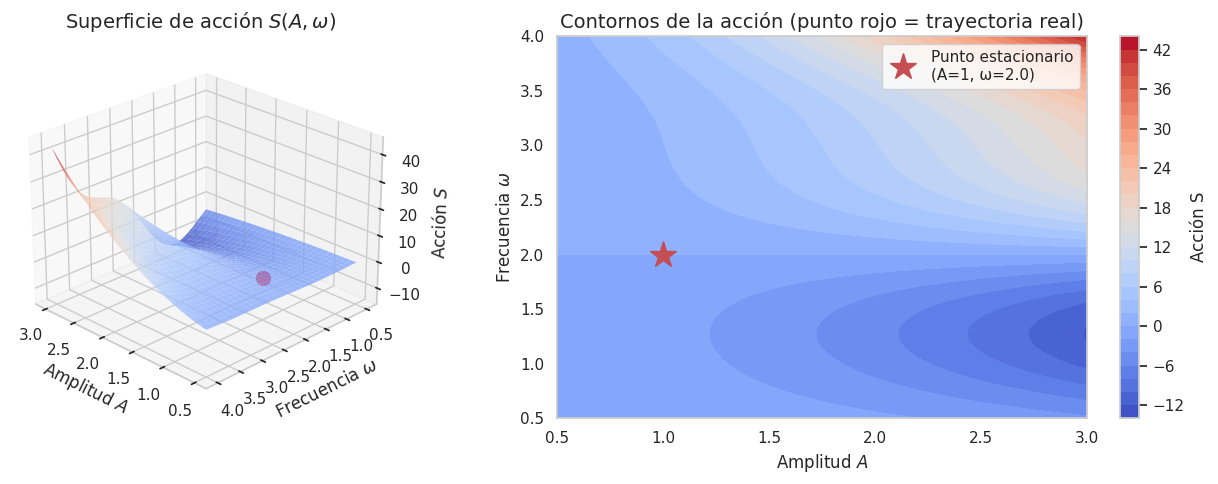

✅ Frecuencia natural: ω = √(k/m) = √(4.0/1.0) = 2.00 rad/s
   La acción es estacionaria (punto silla) en la trayectoria física real.


In [9]:
# Oscilador armónico: Superficie de acción en el espacio de parámetros
# Parametrizamos trayectorias de prueba como x(t) = A*sin(ω*t) y variamos A y ω

m_osc, k_osc = 1.0, 4.0  # ω_real = 2
omega_real = np.sqrt(k_osc / m_osc)
t_osc = np.linspace(0, np.pi / omega_real, 500)  # medio período

A_range = np.linspace(0.5, 3.0, 60)
omega_range = np.linspace(0.5, 4.0, 60)
A_grid, W_grid = np.meshgrid(A_range, omega_range)
S_grid = np.zeros_like(A_grid)

for i in range(len(omega_range)):
    for j in range(len(A_range)):
        A = A_range[j]
        w = omega_range[i]
        x_trial = A * np.sin(w * t_osc)
        x_dot_trial = A * w * np.cos(w * t_osc)
        T_trial = 0.5 * m_osc * x_dot_trial**2
        V_trial = 0.5 * k_osc * x_trial**2
        L_trial = T_trial - V_trial
        S_grid[i, j] = np.trapezoid(L_trial, t_osc)

fig = plt.figure(figsize=(14, 5))

# Superficie 3D
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(A_grid, W_grid, S_grid, cmap='coolwarm', alpha=0.8, 
                         edgecolor='none', antialiased=True)
ax1.set_xlabel('Amplitud $A$')
ax1.set_ylabel('Frecuencia $\\omega$')
ax1.set_zlabel('Acción $S$')
ax1.set_title('Superficie de acción $S(A, \\omega)$')

# Marcar punto estacionario
idx_A = np.argmin(np.abs(A_range - 1.0))
idx_w = np.argmin(np.abs(omega_range - omega_real))
ax1.scatter([1.0], [omega_real], [S_grid[idx_w, idx_A]], color='red', s=100, zorder=5)
ax1.view_init(elev=25, azim=135)

# Contorno 2D
ax2 = fig.add_subplot(122)
contour = ax2.contourf(A_grid, W_grid, S_grid, levels=30, cmap='coolwarm')
plt.colorbar(contour, ax=ax2, label='Acción S')
ax2.plot(1.0, omega_real, 'r*', markersize=20, label=f'Punto estacionario\n(A=1, ω={omega_real:.1f})')
ax2.set_xlabel('Amplitud $A$')
ax2.set_ylabel('Frecuencia $\\omega$')
ax2.set_title('Contornos de la acción (punto rojo = trayectoria real)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"✅ Frecuencia natural: ω = √(k/m) = √({k_osc}/{m_osc}) = {omega_real:.2f} rad/s")
print(f"   La acción es estacionaria (punto silla) en la trayectoria física real.")

### 5.3 Péndulo Doble: Caos Determinista

El péndulo doble es un ejemplo icónico de **caos en mecánica clásica**. Con solo 2 grados de libertad, exhibe sensibilidad extrema a condiciones iniciales.

**Lagrangiano del péndulo doble:**

$$L = \frac{1}{2}(m_1 + m_2)l_1^2\dot{\theta}_1^2 + \frac{1}{2}m_2 l_2^2 \dot{\theta}_2^2 + m_2 l_1 l_2 \dot{\theta}_1 \dot{\theta}_2 \cos(\theta_1 - \theta_2)$$
$$+ (m_1 + m_2)g l_1 \cos\theta_1 + m_2 g l_2 \cos\theta_2$$

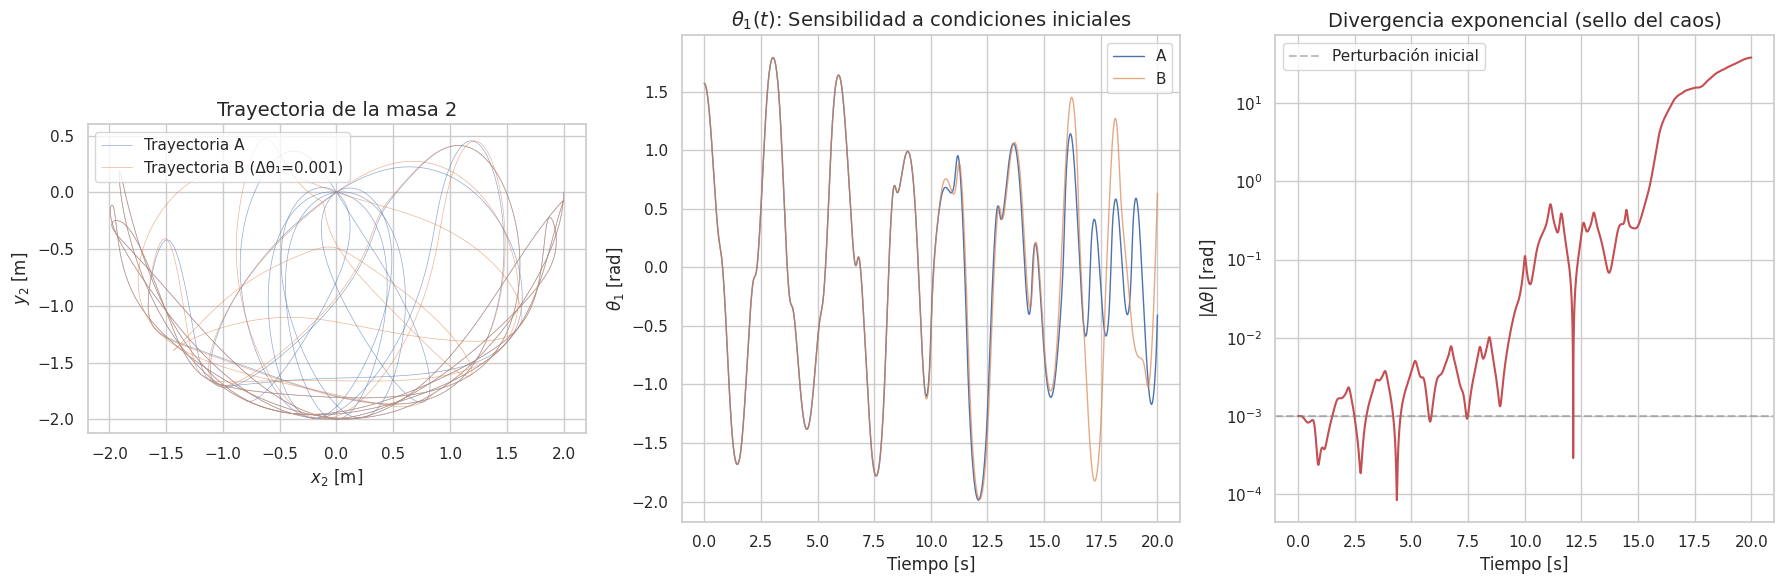

🌀 El péndulo doble muestra CAOS DETERMINISTA:
   - Ecuaciones deterministas → comportamiento impredecible
   - Sensibilidad exponencial a condiciones iniciales
   - Todo derivado del Lagrangiano via Euler-Lagrange


In [10]:
# Péndulo doble: ecuaciones derivadas del Lagrangiano y simulación

def double_pendulum(t, state, m1, m2, l1, l2, g):
    """Ecuaciones de movimiento del péndulo doble (derivadas del Lagrangiano)."""
    th1, w1, th2, w2 = state
    delta = th2 - th1
    
    den1 = (m1 + m2) * l1 - m2 * l1 * np.cos(delta)**2
    den2 = (l2 / l1) * den1
    
    dw1 = (m2 * l1 * w1**2 * np.sin(delta) * np.cos(delta) +
           m2 * g * np.sin(th2) * np.cos(delta) +
           m2 * l2 * w2**2 * np.sin(delta) -
           (m1 + m2) * g * np.sin(th1)) / den1
    
    dw2 = (-m2 * l2 * w2**2 * np.sin(delta) * np.cos(delta) +
           (m1 + m2) * g * np.sin(th1) * np.cos(delta) -
           (m1 + m2) * l1 * w1**2 * np.sin(delta) -
           (m1 + m2) * g * np.sin(th2)) / den2
    
    return [w1, dw1, w2, dw2]

# Parámetros
m1, m2, l1, l2, g = 1.0, 1.0, 1.0, 1.0, 9.81
t_dp = np.linspace(0, 20, 5000)

# Dos condiciones iniciales muy cercanas (caos)
state0_a = [np.pi/2, 0, np.pi/2, 0]
state0_b = [np.pi/2 + 0.001, 0, np.pi/2, 0]  # perturbación de 0.001 rad

sol_a = solve_ivp(double_pendulum, (0, 20), state0_a, args=(m1, m2, l1, l2, g),
                  t_eval=t_dp, method='RK45', rtol=1e-10)
sol_b = solve_ivp(double_pendulum, (0, 20), state0_b, args=(m1, m2, l1, l2, g),
                  t_eval=t_dp, method='RK45', rtol=1e-10)

# Coordenadas cartesianas
def dp_cartesian(sol, l1, l2):
    x1 = l1 * np.sin(sol.y[0])
    y1 = -l1 * np.cos(sol.y[0])
    x2 = x1 + l2 * np.sin(sol.y[2])
    y2 = y1 - l2 * np.cos(sol.y[2])
    return x1, y1, x2, y2

x1a, y1a, x2a, y2a = dp_cartesian(sol_a, l1, l2)
x1b, y1b, x2b, y2b = dp_cartesian(sol_b, l1, l2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Trayectoria de la masa 2
ax1 = axes[0]
ax1.plot(x2a, y2a, 'C0', alpha=0.6, linewidth=0.5, label='Trayectoria A')
ax1.plot(x2b, y2b, 'C1', alpha=0.6, linewidth=0.5, label='Trayectoria B (Δθ₁=0.001)')
ax1.set_xlabel("$x_2$ [m]")
ax1.set_ylabel("$y_2$ [m]")
ax1.set_title("Trayectoria de la masa 2")
ax1.legend()
ax1.set_aspect('equal')

# Panel 2: θ₁(t) - divergencia caótica
ax2 = axes[1]
ax2.plot(sol_a.t, sol_a.y[0], 'C0', linewidth=1, label='A')
ax2.plot(sol_b.t, sol_b.y[0], 'C1', linewidth=1, alpha=0.7, label='B')
ax2.set_xlabel("Tiempo [s]")
ax2.set_ylabel("$\\theta_1$ [rad]")
ax2.set_title("$\\theta_1(t)$: Sensibilidad a condiciones iniciales")
ax2.legend()

# Panel 3: Divergencia exponencial
ax3 = axes[2]
delta_theta = np.sqrt((sol_a.y[0] - sol_b.y[0])**2 + (sol_a.y[2] - sol_b.y[2])**2)
ax3.semilogy(sol_a.t, delta_theta, 'C3', linewidth=1.5)
ax3.set_xlabel("Tiempo [s]")
ax3.set_ylabel("$|\\Delta\\theta|$ [rad]")
ax3.set_title("Divergencia exponencial (sello del caos)")
ax3.axhline(y=0.001, color='gray', linestyle='--', alpha=0.5, label='Perturbación inicial')
ax3.legend()

plt.tight_layout()
plt.show()

print("🌀 El péndulo doble muestra CAOS DETERMINISTA:")
print("   - Ecuaciones deterministas → comportamiento impredecible")
print("   - Sensibilidad exponencial a condiciones iniciales")
print("   - Todo derivado del Lagrangiano via Euler-Lagrange")

---

## 6. Mecánica Hamiltoniana

### 6.1 Transformación de Legendre

La mecánica hamiltoniana reformula el problema en términos de **posiciones** $q_i$ y **momentos canónicos** $p_i$:

$$p_i = \frac{\partial L}{\partial \dot{q}_i}$$

### 6.2 El Hamiltoniano

El **Hamiltoniano** se define via la **transformación de Legendre** del Lagrangiano:

$$\boxed{H(q, p, t) = \sum_i p_i \dot{q}_i - L(q, \dot{q}, t)}$$

Para sistemas conservativos con restricciones independientes del tiempo: **$H = T + V = E$** (energía total).

### 6.3 Ecuaciones de Hamilton

Las ecuaciones de Euler-Lagrange (2° orden) se transforman en un sistema de ecuaciones de **primer orden**:

$$\boxed{\dot{q}_i = \frac{\partial H}{\partial p_i}, \qquad \dot{p}_i = -\frac{\partial H}{\partial q_i}}$$

Estas ecuaciones tienen una **estructura simpléctica** que preserva el volumen en el espacio de fases (teorema de Liouville).

### 6.4 Espacio de fases

El espacio de fases $(q, p)$ es el escenario natural de la mecánica hamiltoniana. Cada punto representa un estado completo del sistema, y la evolución temporal es un **flujo** en este espacio.

In [11]:
# Derivación simbólica: Del Lagrangiano al Hamiltoniano

print("═" * 60)
print("  DEL LAGRANGIANO AL HAMILTONIANO: Péndulo Simple")
print("═" * 60)

# Reutilizamos símbolos
theta_t = theta_sym(t_sym)
theta_dot = diff(theta_t, t_sym)

# Lagrangiano del péndulo
L_pend_sym = Rational(1, 2) * m_sym * l_sym**2 * theta_dot**2 + m_sym * g_sym * l_sym * cos(theta_t)

print("\n1. Lagrangiano:")
display(Math(r"L = " + latex(L_pend_sym)))

# Momento canónico
p_theta = diff(L_pend_sym, theta_dot)
print("\n2. Momento canónico conjugado:")
display(Math(r"p_\theta = \frac{\partial L}{\partial \dot{\theta}} = " + latex(p_theta)))

# Despejamos theta_dot en función de p
p_sym = symbols('p_theta')
theta_dot_of_p = sp_solve(Eq(p_sym, p_theta), theta_dot)[0]
print("\n3. Despejando θ̇:")
display(Math(r"\dot{\theta} = " + latex(theta_dot_of_p)))

# Hamiltoniano
H_sym = p_sym * theta_dot_of_p - L_pend_sym.subs(theta_dot, theta_dot_of_p)
H_sym = simplify(H_sym)
print("\n4. Hamiltoniano H = pθ̇ - L:")
display(Math(r"H = " + latex(H_sym)))

# Ecuaciones de Hamilton
theta_gen = symbols('theta')
H_explicit = p_sym**2 / (2 * m_sym * l_sym**2) - m_sym * g_sym * l_sym * cos(theta_gen)

print("\n5. Ecuaciones de Hamilton:")
dH_dp = diff(H_explicit, p_sym)
dH_dtheta = diff(H_explicit, theta_gen)
display(Math(r"\dot{\theta} = \frac{\partial H}{\partial p_\theta} = " + latex(dH_dp)))
display(Math(r"\dot{p}_\theta = -\frac{\partial H}{\partial \theta} = " + latex(-dH_dtheta)))

print("\n✅ H = T + V = Energía total (constante de movimiento)")

════════════════════════════════════════════════════════════
  DEL LAGRANGIANO AL HAMILTONIANO: Péndulo Simple
════════════════════════════════════════════════════════════

1. Lagrangiano:


<IPython.core.display.Math object>


2. Momento canónico conjugado:


<IPython.core.display.Math object>


3. Despejando θ̇:


...

<IPython.core.display.Math object>


5. Ecuaciones de Hamilton:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


✅ H = T + V = Energía total (constante de movimiento)


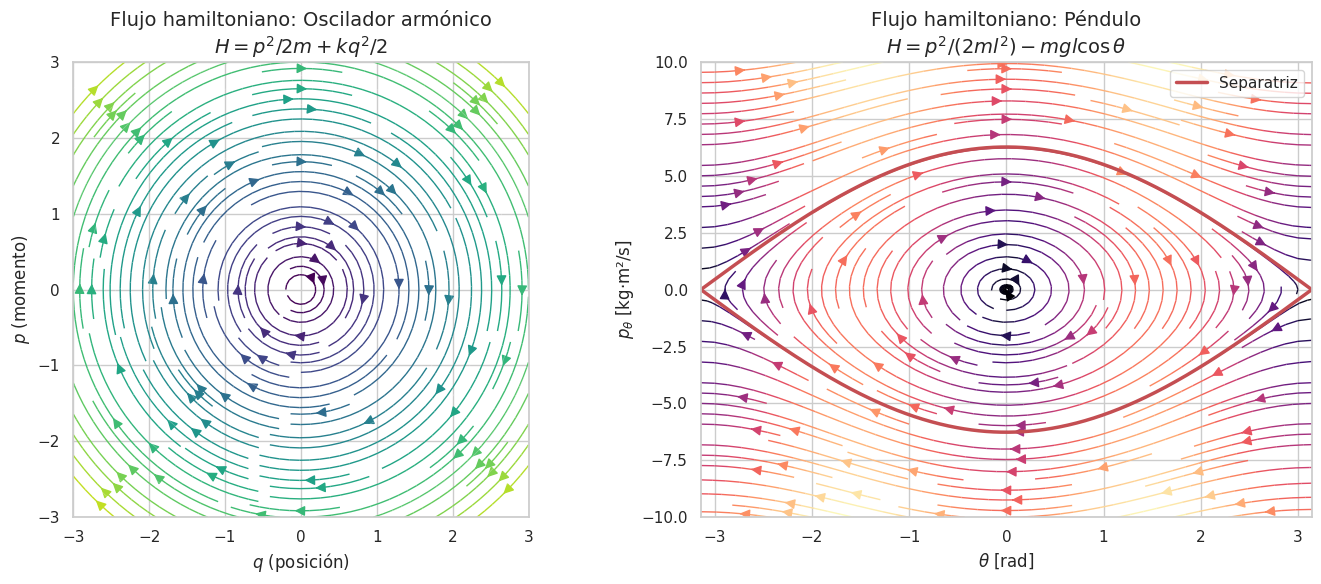

📐 Propiedades del flujo hamiltoniano:
   • Las trayectorias siguen contornos de H = constante
   • El flujo preserva el volumen (teorema de Liouville)
   • La separatriz (roja) divide regiones cualitativamente distintas


In [12]:
# Flujo hamiltoniano en el espacio de fases: Oscilador armónico y péndulo

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ───── Oscilador Armónico ─────
ax1 = axes[0]
m_h, k_h = 1.0, 1.0  # ω = 1

# Campo vectorial hamiltoniano: dq/dt = ∂H/∂p = p/m, dp/dt = -∂H/∂q = -kq
q_grid = np.linspace(-3, 3, 20)
p_grid = np.linspace(-3, 3, 20)
Q, P = np.meshgrid(q_grid, p_grid)
dQ = P / m_h
dP = -k_h * Q

# Normalizar para mejor visualización
speed = np.sqrt(dQ**2 + dP**2)
dQ_n = dQ / speed
dP_n = dP / speed

ax1.streamplot(Q, P, dQ, dP, color=speed, cmap='viridis', linewidth=1, density=1.5, arrowsize=1.5)

# Contornos de energía constante
H_grid = P**2/(2*m_h) + 0.5*k_h*Q**2
ax1.contour(Q, P, H_grid, levels=10, colors='white', alpha=0.3, linewidths=0.5)

ax1.set_xlabel("$q$ (posición)")
ax1.set_ylabel("$p$ (momento)")
ax1.set_title("Flujo hamiltoniano: Oscilador armónico\n$H = p^2/2m + kq^2/2$")
ax1.set_aspect('equal')

# ───── Péndulo ─────
ax2 = axes[1]
g_h, l_h, m_pend = 9.81, 1.0, 1.0

theta_grid = np.linspace(-np.pi, np.pi, 25)
p_theta_grid = np.linspace(-10, 10, 25)
TH, PTH = np.meshgrid(theta_grid, p_theta_grid)

# dθ/dt = p/(ml²), dp/dt = -mgl sin(θ)
dTH = PTH / (m_pend * l_h**2)
dPTH = -m_pend * g_h * l_h * np.sin(TH)

speed2 = np.sqrt(dTH**2 + dPTH**2)

ax2.streamplot(TH, PTH, dTH, dPTH, color=speed2, cmap='magma', linewidth=1, density=1.5, arrowsize=1.5)

# Separatriz
th_s = np.linspace(-np.pi + 0.01, np.pi - 0.01, 500)
E_sep = m_pend * g_h * l_h  # energía en el punto inestable
p_sep_pos = np.sqrt(2 * m_pend * l_h**2 * (E_sep + m_pend * g_h * l_h * np.cos(th_s)))
p_sep_neg = -p_sep_pos
mask = ~np.isnan(p_sep_pos)
ax2.plot(th_s[mask], p_sep_pos[mask], 'r-', linewidth=2.5, label='Separatriz')
ax2.plot(th_s[mask], p_sep_neg[mask], 'r-', linewidth=2.5)

ax2.set_xlabel(r"$\theta$ [rad]")
ax2.set_ylabel(r"$p_\theta$ [kg·m²/s]")
ax2.set_title("Flujo hamiltoniano: Péndulo\n$H = p^2/(2ml^2) - mgl\\cos\\theta$")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("📐 Propiedades del flujo hamiltoniano:")
print("   • Las trayectorias siguen contornos de H = constante")
print("   • El flujo preserva el volumen (teorema de Liouville)")
print("   • La separatriz (roja) divide regiones cualitativamente distintas")

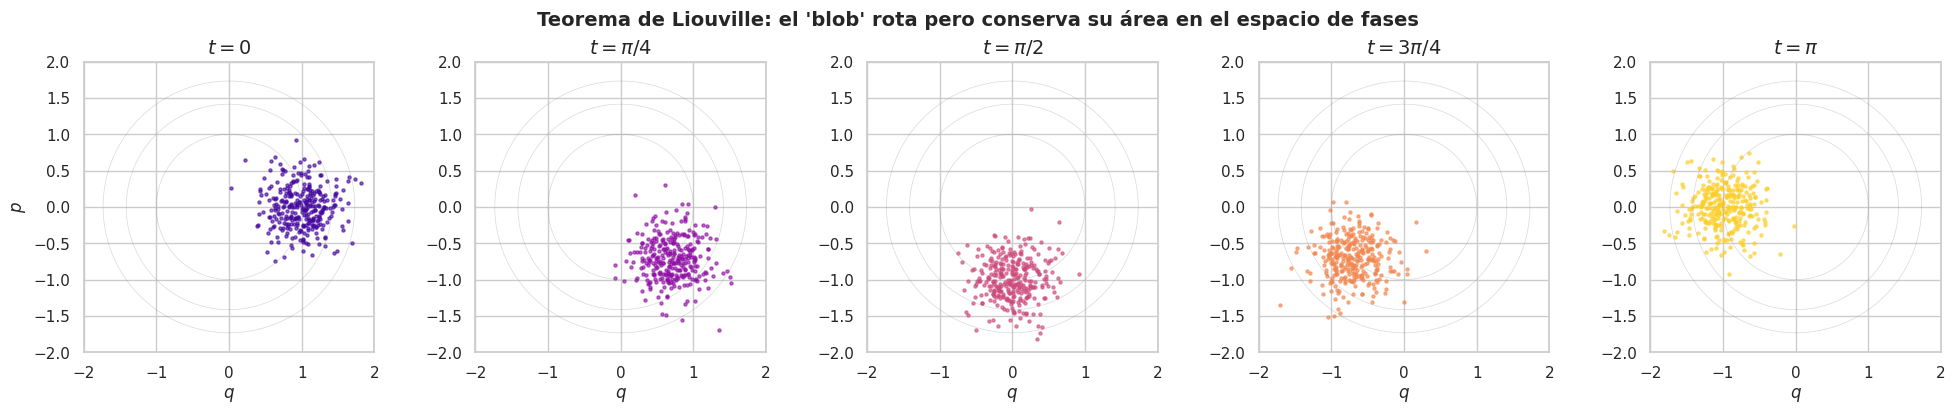

✅ Teorema de Liouville: El flujo hamiltoniano preserva el volumen del espacio de fases.
   El blob rota (evolución temporal) pero nunca se comprime ni se expande.


In [13]:
# Verificación del Teorema de Liouville: conservación del volumen en el espacio de fases

def hamiltonian_oscillator(t, state):
    """Oscilador armónico: H = p²/2 + q²/2"""
    q, p = state
    return [p, -q]  # dq/dt = ∂H/∂p, dp/dt = -∂H/∂q

# Crear un "blob" de condiciones iniciales en el espacio de fases
n_points = 300
np.random.seed(42)
q0_blob = 1.0 + 0.3 * np.random.randn(n_points)
p0_blob = 0.0 + 0.3 * np.random.randn(n_points)

# Evolucionar cada punto
times_liouville = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
labels_t = ['$t = 0$', '$t = \\pi/4$', '$t = \\pi/2$', '$t = 3\\pi/4$', '$t = \\pi$']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors_liouville = plt.cm.plasma(np.linspace(0.1, 0.9, 5))

for idx, (t_end, label, color) in enumerate(zip(times_liouville, labels_t, colors_liouville)):
    q_evolved = []
    p_evolved = []
    for q0, p0 in zip(q0_blob, p0_blob):
        if t_end == 0:
            q_evolved.append(q0)
            p_evolved.append(p0)
        else:
            sol = solve_ivp(hamiltonian_oscillator, (0, t_end), [q0, p0], 
                           method='RK45', rtol=1e-12)
            q_evolved.append(sol.y[0, -1])
            p_evolved.append(sol.y[1, -1])
    
    ax = axes[idx]
    ax.scatter(q_evolved, p_evolved, s=5, alpha=0.6, color=color)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_xlabel("$q$")
    if idx == 0:
        ax.set_ylabel("$p$")
    ax.set_title(label)
    ax.set_aspect('equal')
    
    # Dibujar contornos de energía
    q_c = np.linspace(-2, 2, 100)
    p_c = np.linspace(-2, 2, 100)
    QC, PC = np.meshgrid(q_c, p_c)
    HC = QC**2/2 + PC**2/2
    ax.contour(QC, PC, HC, levels=[0.5, 1.0, 1.5], colors='gray', alpha=0.3, linewidths=0.5)

plt.suptitle("Teorema de Liouville: el 'blob' rota pero conserva su área en el espacio de fases", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Teorema de Liouville: El flujo hamiltoniano preserva el volumen del espacio de fases.")
print("   El blob rota (evolución temporal) pero nunca se comprime ni se expande.")

---

## 7. Teorema de Noether: Simetrías y Leyes de Conservación

### La conexión más profunda de la física

> **Teorema de Noether (1918):** A cada **simetría continua** del Lagrangiano le corresponde una **cantidad conservada** (y viceversa).

Este es posiblemente el teorema más importante de la física teórica. Conecta dos ideas aparentemente distintas: **simetrías** y **leyes de conservación**.

### Correspondencias fundamentales

| Simetría | Transformación | Cantidad conservada |
|----------|---------------|-------------------|
| Homogeneidad temporal | $t \to t + \epsilon$ | Energía $E$ |
| Homogeneidad espacial | $\vec{r} \to \vec{r} + \vec{\epsilon}$ | Momento lineal $\vec{p}$ |
| Isotropía espacial | $\vec{r} \to R(\epsilon)\vec{r}$ | Momento angular $\vec{L}$ |

### Formulación matemática

Si el Lagrangiano es invariante bajo la transformación infinitesimal $q_i \to q_i + \epsilon \, \eta_i(q, t)$, entonces la cantidad:

$$\boxed{Q = \sum_i \frac{\partial L}{\partial \dot{q}_i} \eta_i}$$

es una **constante de movimiento**: $\frac{dQ}{dt} = 0$.

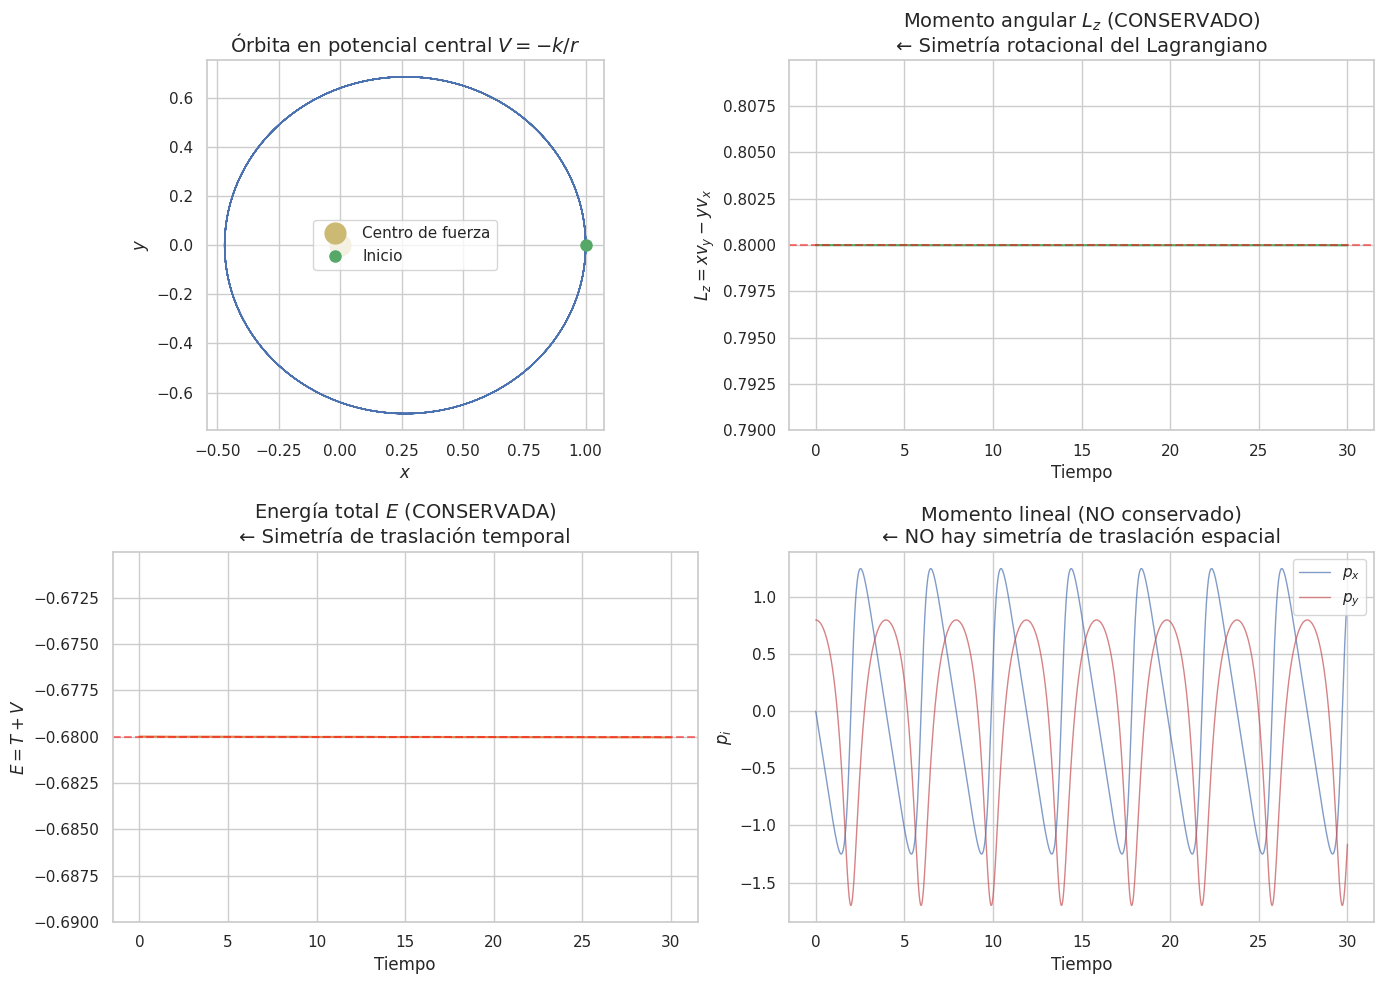

════════════════════════════════════════════════════════════
  RESUMEN: Teorema de Noether en acción
════════════════════════════════════════════════════════════
  • V(r) = -k/r tiene simetría rotacional → Lz = cte = 0.800000
  • L no depende de t → E = cte = -0.680000
  • V(r) NO tiene simetría traslacional → p NO se conserva


In [14]:
# Demostración numérica del Teorema de Noether
# Ejemplo: Partícula en potencial central → conservación del momento angular

def central_force(t, state, k=1.0):
    """Partícula en potencial central V(r) = -k/r (Kepler)"""
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    r3 = r**3
    ax = -k * x / r3
    ay = -k * y / r3
    return [vx, vy, ax, ay]

# Condiciones iniciales (órbita elíptica)
x0, y0 = 1.0, 0.0
vx0, vy0 = 0.0, 0.8  # velocidad < escape

sol_kepler = solve_ivp(central_force, (0, 30), [x0, y0, vx0, vy0],
                       t_eval=np.linspace(0, 30, 5000), method='RK45', rtol=1e-12)

x_k, y_k = sol_kepler.y[0], sol_kepler.y[1]
vx_k, vy_k = sol_kepler.y[2], sol_kepler.y[3]

# Cantidades conservadas
r_k = np.sqrt(x_k**2 + y_k**2)
L_angular = x_k * vy_k - y_k * vx_k  # Lz = x*vy - y*vx (momento angular)
E_total_k = 0.5 * (vx_k**2 + vy_k**2) - 1.0 / r_k  # Energía total
p_linear = np.sqrt(vx_k**2 + vy_k**2)  # |p| (NO conservado)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Órbita
ax1 = axes[0, 0]
ax1.plot(x_k, y_k, 'C0', linewidth=1)
ax1.plot(0, 0, 'yo', markersize=15, label='Centro de fuerza')
ax1.plot(x_k[0], y_k[0], 'go', markersize=8, label='Inicio')
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")
ax1.set_title("Órbita en potencial central $V = -k/r$")
ax1.set_aspect('equal')
ax1.legend()

# Panel 2: Momento angular (CONSERVADO - simetría rotacional)
ax2 = axes[0, 1]
ax2.plot(sol_kepler.t, L_angular, 'C2', linewidth=1.5)
ax2.set_xlabel("Tiempo")
ax2.set_ylabel("$L_z = x v_y - y v_x$")
ax2.set_title("Momento angular $L_z$ (CONSERVADO)\n← Simetría rotacional del Lagrangiano")
ax2.set_ylim([L_angular.mean() - 0.01, L_angular.mean() + 0.01])
ax2.axhline(y=L_angular[0], color='red', linestyle='--', alpha=0.5)

# Panel 3: Energía (CONSERVADA - simetría temporal)
ax3 = axes[1, 0]
ax3.plot(sol_kepler.t, E_total_k, 'C1', linewidth=1.5)
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("$E = T + V$")
ax3.set_title("Energía total $E$ (CONSERVADA)\n← Simetría de traslación temporal")
ax3.set_ylim([E_total_k.mean() - 0.01, E_total_k.mean() + 0.01])
ax3.axhline(y=E_total_k[0], color='red', linestyle='--', alpha=0.5)

# Panel 4: Momento lineal (NO conservado - NO hay simetría traslacional)
ax4 = axes[1, 1]
ax4.plot(sol_kepler.t, vx_k, 'C0', linewidth=1, alpha=0.7, label='$p_x$')
ax4.plot(sol_kepler.t, vy_k, 'C3', linewidth=1, alpha=0.7, label='$p_y$')
ax4.set_xlabel("Tiempo")
ax4.set_ylabel("$p_i$")
ax4.set_title("Momento lineal (NO conservado)\n← NO hay simetría de traslación espacial")
ax4.legend()

plt.tight_layout()
plt.show()

print("═" * 60)
print("  RESUMEN: Teorema de Noether en acción")
print("═" * 60)
print(f"  • V(r) = -k/r tiene simetría rotacional → Lz = cte = {L_angular[0]:.6f}")
print(f"  • L no depende de t → E = cte = {E_total_k[0]:.6f}")
print(f"  • V(r) NO tiene simetría traslacional → p NO se conserva")

---

## 8. Ejercicios Propuestos

### Nivel 1: Fundamentos

**Ejercicio 1.1** - Demuestre que la curva que minimiza $J[y] = \int_0^1 (y')^2 \, dx$ con $y(0)=0$, $y(1)=1$ es una línea recta.

**Ejercicio 1.2** - Encuentre la ecuación de Euler-Lagrange para $J[y] = \int_0^1 [(y')^2 + y^2] \, dx$.

**Ejercicio 1.3** - Verifique que para un potencial $V(x) = \frac{1}{2}kx^2$, la ecuación de E-L del Lagrangiano $L = T - V$ reproduce la ley de Hooke.

### Nivel 2: Mecánica Lagrangiana

**Ejercicio 2.1** - Obtenga el Lagrangiano y las ecuaciones de movimiento para una partícula sobre un plano inclinado sin fricción de ángulo $\alpha$.

**Ejercicio 2.2** - Derive las ecuaciones de movimiento para una partícula confinada a moverse sobre la superficie de un cono $z = \alpha\sqrt{x^2 + y^2}$ bajo gravedad.

**Ejercicio 2.3** - Para el péndulo simple, calcule numéricamente el período exacto usando la integral elíptica completa:
$$T = 4\sqrt{\frac{l}{g}} K(\sin^2(\theta_0/2))$$

### Nivel 3: Mecánica Hamiltoniana

**Ejercicio 3.1** - Obtenga el Hamiltoniano para el oscilador armónico amortiguado con $L = e^{\gamma t}[\frac{1}{2}m\dot{x}^2 - \frac{1}{2}kx^2]$ y encuentre las ecuaciones de Hamilton.

**Ejercicio 3.2** - Para una partícula cargada en un campo magnético uniforme, escriba el Lagrangiano $L = \frac{1}{2}m\dot{\vec{r}}^2 + \frac{q}{c}\dot{\vec{r}} \cdot \vec{A}$ y obtenga las ecuaciones de Hamilton.

**Ejercicio 3.3** - Demuestre numéricamente el teorema de Liouville para el péndulo (no lineal): tome un conjunto de condiciones iniciales y verifique que el área del espacio de fases se conserva.

### Nivel 4: Noether y Simetrías

**Ejercicio 4.1** - Para $L = \frac{1}{2}m(\dot{x}^2 + \dot{y}^2) - V(x^2 + y^2)$, identifique la simetría rotacional y derive la cantidad conservada usando el teorema de Noether.

**Ejercicio 4.2** - Considere $L = \frac{1}{2}m(\dot{x}^2 + \dot{y}^2 + \dot{z}^2) - mgz$. ¿Qué simetrías tiene? ¿Qué cantidades se conservan?

---

A continuación, resolveremos algunos de estos ejercicios como ejemplo.

════════════════════════════════════════════════════════════
  Ejercicio 1.1: Minimizar J[y] = ∫₀¹ (y')² dx
  con y(0) = 0, y(1) = 1
════════════════════════════════════════════════════════════

F(x, y, y') = (y')²
∂F/∂y = 0 = 0
∂F/∂y' = 2*y' = 2y'

Ecuación de E-L: 0 - d/dx(2y') = 0
⟹ y'' = 0  ⟹  y = ax + b

Condiciones de frontera: y(0)=0 → b=0, y(1)=1 → a=1
✅ Solución: y(x) = x  (línea recta)


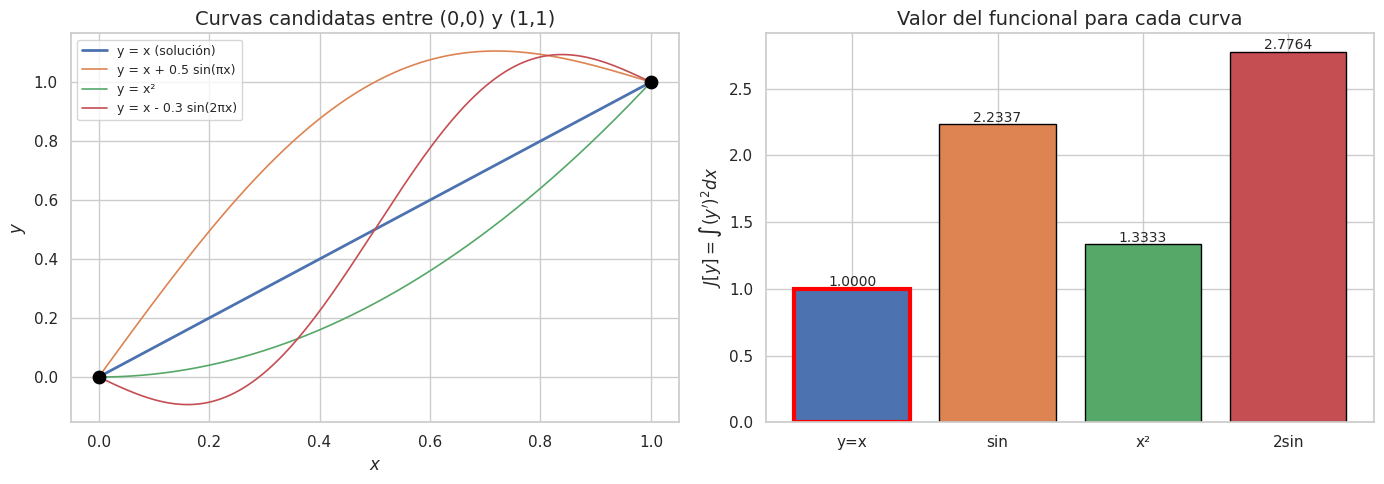

In [15]:
# ═══════════════════════════════════════════════════
# SOLUCIÓN Ejercicio 1.1: Minimizar J[y] = ∫(y')² dx
# ═══════════════════════════════════════════════════

print("═" * 60)
print("  Ejercicio 1.1: Minimizar J[y] = ∫₀¹ (y')² dx")
print("  con y(0) = 0, y(1) = 1")
print("═" * 60)

# Solución simbólica
x_s = symbols('x')
y_s = Function('y')
yp_s = symbols("y'")

F_11 = yp_s**2
print(f"\nF(x, y, y') = (y')²")
print(f"∂F/∂y = {diff(F_11, symbols('y'))} = 0")
print(f"∂F/∂y' = {diff(F_11, yp_s)} = 2y'")
print(f"\nEcuación de E-L: 0 - d/dx(2y') = 0")
print(f"⟹ y'' = 0  ⟹  y = ax + b")
print(f"\nCondiciones de frontera: y(0)=0 → b=0, y(1)=1 → a=1")
print(f"✅ Solución: y(x) = x  (línea recta)")

# Verificación numérica: comparar acción para diferentes curvas
x_ex = np.linspace(0, 1, 500)
y_recta = x_ex
y_curva1 = x_ex + 0.5 * np.sin(np.pi * x_ex)
y_curva2 = x_ex**2
y_curva3 = x_ex - 0.3 * np.sin(2 * np.pi * x_ex)

curves_ex = [
    (y_recta, "y = x (solución)", "C0"),
    (y_curva1, "y = x + 0.5 sin(πx)", "C1"),
    (y_curva2, "y = x²", "C2"),
    (y_curva3, "y = x - 0.3 sin(2πx)", "C3"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
actions_ex = []
for yc, label, color in curves_ex:
    yp_num = np.gradient(yc, x_ex)
    J = np.trapezoid(yp_num**2, x_ex)
    actions_ex.append(J)
    ax1.plot(x_ex, yc, color=color, linewidth=2 if "solución" in label else 1.2, label=label)

ax1.scatter([0, 1], [0, 1], color='black', s=80, zorder=5)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")
ax1.set_title("Curvas candidatas entre (0,0) y (1,1)")
ax1.legend(fontsize=9)

ax2 = axes[1]
labels_ex = ["y=x", "sin", "x²", "2sin"]
colors_ex = ["C0", "C1", "C2", "C3"]
bars_ex = ax2.bar(labels_ex, actions_ex, color=colors_ex, edgecolor='black')
ax2.set_ylabel("$J[y] = \\int (y')^2 dx$")
ax2.set_title("Valor del funcional para cada curva")
for bar, val in zip(bars_ex, actions_ex):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.4f}', ha='center', fontsize=10)
bars_ex[0].set_edgecolor('red')
bars_ex[0].set_linewidth(3)

plt.tight_layout()
plt.show()

════════════════════════════════════════════════════════════
  Ejercicio 2.3: Período exacto del péndulo simple
════════════════════════════════════════════════════════════


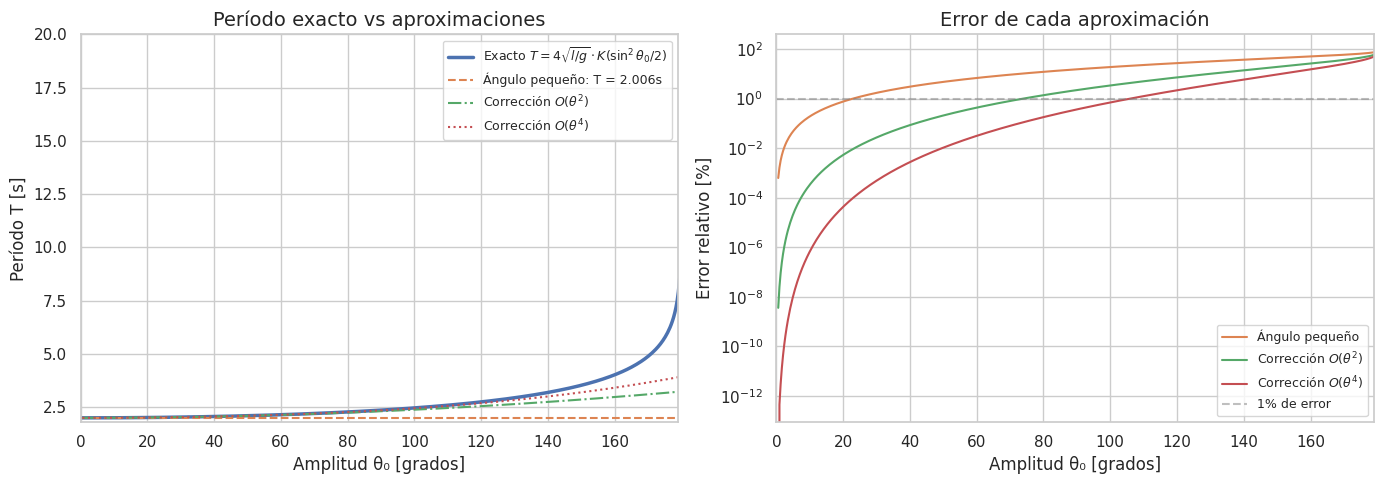


    θ₀ [°]   T exacto [s]   T lineal [s]    Error [%]
───────────────────────────────────────────────────────
         5       2.007022       2.006067       0.048%
        15       2.014694       2.006067       0.430%
        30       2.040990       2.006067       1.741%
        45       2.086256       2.006067       3.997%
        60       2.152875       2.006067       7.318%
        90       2.367842       2.006067      18.034%
       120       2.754090       2.006067      37.288%
       150       3.535098       2.006067      76.220%
       170       4.893524       2.006067     143.936%


In [16]:
# ═══════════════════════════════════════════════════
# SOLUCIÓN Ejercicio 2.3: Período exacto del péndulo con integrales elípticas
# ═══════════════════════════════════════════════════
from scipy.special import ellipk

print("═" * 60)
print("  Ejercicio 2.3: Período exacto del péndulo simple")
print("═" * 60)

g_ex, l_ex = 9.81, 1.0
T_small = 2 * np.pi * np.sqrt(l_ex / g_ex)

theta0_range_ex = np.linspace(0.01, np.pi - 0.01, 500)

# Período exacto: T = 4√(l/g) · K(sin²(θ₀/2))
T_exact = 4 * np.sqrt(l_ex / g_ex) * ellipk(np.sin(theta0_range_ex / 2)**2)

# Aproximaciones
T_small_angle = T_small * np.ones_like(theta0_range_ex)
T_second_order = T_small * (1 + theta0_range_ex**2 / 16)  # corrección O(θ²)
T_fourth_order = T_small * (1 + theta0_range_ex**2 / 16 + 11 * theta0_range_ex**4 / 3072)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Período vs amplitud
ax1 = axes[0]
ax1.plot(np.degrees(theta0_range_ex), T_exact, 'C0', linewidth=2.5, label='Exacto $T = 4\\sqrt{l/g} \\cdot K(\\sin^2\\theta_0/2)$')
ax1.plot(np.degrees(theta0_range_ex), T_small_angle, 'C1--', linewidth=1.5, label=f'Ángulo pequeño: T = {T_small:.3f}s')
ax1.plot(np.degrees(theta0_range_ex), T_second_order, 'C2-.', linewidth=1.5, label='Corrección $O(\\theta^2)$')
ax1.plot(np.degrees(theta0_range_ex), T_fourth_order, 'C3:', linewidth=1.5, label='Corrección $O(\\theta^4)$')
ax1.set_xlabel("Amplitud θ₀ [grados]")
ax1.set_ylabel("Período T [s]")
ax1.set_title("Período exacto vs aproximaciones")
ax1.legend(fontsize=9)
ax1.set_xlim(0, 179)
ax1.set_ylim(1.8, 20)

# Panel 2: Error relativo
ax2 = axes[1]
err_small = np.abs(T_small_angle - T_exact) / T_exact * 100
err_second = np.abs(T_second_order - T_exact) / T_exact * 100
err_fourth = np.abs(T_fourth_order - T_exact) / T_exact * 100

ax2.semilogy(np.degrees(theta0_range_ex), err_small, 'C1', linewidth=1.5, label='Ángulo pequeño')
ax2.semilogy(np.degrees(theta0_range_ex), err_second, 'C2', linewidth=1.5, label='Corrección $O(\\theta^2)$')
ax2.semilogy(np.degrees(theta0_range_ex), err_fourth, 'C3', linewidth=1.5, label='Corrección $O(\\theta^4)$')
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='1% de error')
ax2.set_xlabel("Amplitud θ₀ [grados]")
ax2.set_ylabel("Error relativo [%]")
ax2.set_title("Error de cada aproximación")
ax2.legend(fontsize=9)
ax2.set_xlim(0, 179)

plt.tight_layout()
plt.show()

# Tabla de valores
print(f"\n{'θ₀ [°]':>10} {'T exacto [s]':>14} {'T lineal [s]':>14} {'Error [%]':>12}")
print("─" * 55)
for theta_deg in [5, 15, 30, 45, 60, 90, 120, 150, 170]:
    theta_rad = np.radians(theta_deg)
    T_ex = 4 * np.sqrt(l_ex / g_ex) * ellipk(np.sin(theta_rad / 2)**2)
    err = (T_ex - T_small) / T_small * 100
    print(f"{theta_deg:>10} {T_ex:>14.6f} {T_small:>14.6f} {err:>11.3f}%")

════════════════════════════════════════════════════════════
  Ejercicio 2.1: Partícula sobre plano inclinado
════════════════════════════════════════════════════════════


**Coordenada generalizada:** $s$ = distancia a lo largo del plano

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Ecuación de Euler-Lagrange:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


✅ s̈ = g·sin(α)  →  Aceleración constante plano abajo


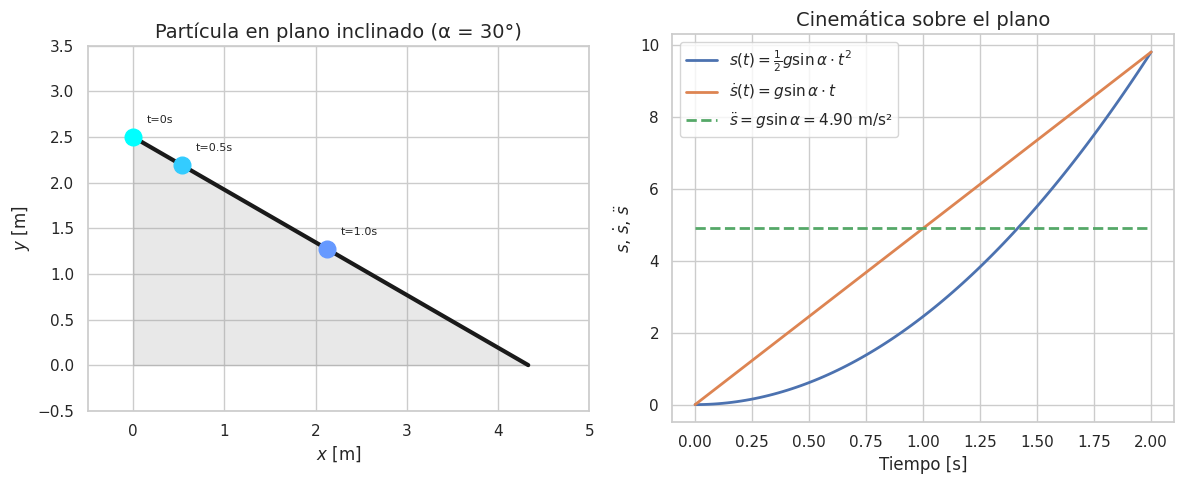

In [17]:
# ═══════════════════════════════════════════════════
# SOLUCIÓN Ejercicio 2.1: Partícula sobre plano inclinado
# ═══════════════════════════════════════════════════

print("═" * 60)
print("  Ejercicio 2.1: Partícula sobre plano inclinado")
print("═" * 60)

# Derivación simbólica
s_sym = Function('s')  # coordenada a lo largo del plano
alpha_sym = symbols('alpha', positive=True)
s_t = s_sym(t_sym)
s_dot = diff(s_t, t_sym)

# T = (1/2)m·ṡ²
T_incl = Rational(1, 2) * m_sym * s_dot**2
# V = mgs·sin(α)  (con s medido plano arriba desde la base)
# Tomamos V negativo si s se mide plano abajo
V_incl = -m_sym * g_sym * s_t * sin(alpha_sym)
L_incl = T_incl - V_incl

display(Markdown("**Coordenada generalizada:** $s$ = distancia a lo largo del plano"))
display(Math(r"T = " + latex(T_incl)))
display(Math(r"V = " + latex(V_incl)))
display(Math(r"L = T - V = " + latex(L_incl)))

# Ecuación de E-L
dL_ds = diff(L_incl, s_t)
dL_dsdot = diff(L_incl, s_dot)
EL_incl = simplify(diff(dL_dsdot, t_sym) - dL_ds)

print("\nEcuación de Euler-Lagrange:")
display(Math(latex(Eq(EL_incl, 0))))
EL_simple_incl = simplify(EL_incl / m_sym)
display(Math(r"\ddot{s} = " + latex(-simplify(dL_ds / m_sym))))
print(f"\n✅ s̈ = g·sin(α)  →  Aceleración constante plano abajo")

# Simulación visual
fig = plt.figure(figsize=(12, 5))

alpha_val = np.radians(30)
t_sim = np.linspace(0, 2, 100)
s_sim = 0.5 * g * np.sin(alpha_val) * t_sim**2

ax1 = fig.add_subplot(121)
# Dibujar plano
plano_x = np.array([0, 5 * np.cos(alpha_val)])
plano_y = np.array([5 * np.sin(alpha_val), 0])
ax1.plot(plano_x, plano_y, 'k-', linewidth=3)
ax1.fill_between(plano_x, plano_y, color='C7', alpha=0.2)

# Posiciones de la partícula en varios instantes
for i, ti in enumerate([0, 0.5, 1.0, 1.5, 2.0]):
    s_i = 0.5 * g * np.sin(alpha_val) * ti**2
    px = s_i * np.cos(alpha_val)
    py = 5 * np.sin(alpha_val) - s_i * np.sin(alpha_val)
    if py >= -0.1:
        color_i = plt.cm.cool(i / 5)
        ax1.plot(px, py, 'o', color=color_i, markersize=12, zorder=5)
        ax1.annotate(f't={ti}s', (px, py), xytext=(10, 10), textcoords='offset points', fontsize=8)

ax1.set_xlabel("$x$ [m]")
ax1.set_ylabel("$y$ [m]")
ax1.set_title(f"Partícula en plano inclinado (α = {np.degrees(alpha_val):.0f}°)")
ax1.set_aspect('equal')
ax1.set_xlim(-0.5, 5)
ax1.set_ylim(-0.5, 3.5)

# s(t), v(t), a(t)
ax2 = fig.add_subplot(122)
v_sim = g * np.sin(alpha_val) * t_sim
a_sim = g * np.sin(alpha_val) * np.ones_like(t_sim)
ax2.plot(t_sim, s_sim, 'C0', linewidth=2, label='$s(t) = \\frac{1}{2}g\\sin\\alpha \\cdot t^2$')
ax2.plot(t_sim, v_sim, 'C1', linewidth=2, label='$\\dot{s}(t) = g\\sin\\alpha \\cdot t$')
ax2.plot(t_sim, a_sim, 'C2--', linewidth=2, label=f'$\\ddot{{s}} = g\\sin\\alpha = {g*np.sin(alpha_val):.2f}$ m/s²')
ax2.set_xlabel("Tiempo [s]")
ax2.set_ylabel("$s$, $\\dot{s}$, $\\ddot{s}$")
ax2.set_title("Cinemática sobre el plano")
ax2.legend()

plt.tight_layout()
plt.show()

---

## Resumen y Mapa Conceptual

```
                    MECÁNICA VARIACIONAL
                          │
          ┌───────────────┼───────────────┐
          │               │               │
    CÁLCULO          MECÁNICA         MECÁNICA
    VARIACIONAL      LAGRANGIANA      HAMILTONIANA
          │               │               │
    Funcionales      L = T - V        H = T + V
    Euler-Lagrange   Coords. gen.     Espacio de fases
    δJ = 0           δS = 0          Ec. de Hamilton
          │               │               │
          └───────┬───────┘               │
                  │                       │
           PRINCIPIO DE              TEOREMA DE
           HAMILTON                  LIOUVILLE
                  │
           TEOREMA DE
           NOETHER
                  │
          Simetrías ↔ Conservación
          ┌──────┼──────┐
          │      │      │
        t→t+ε  r→r+ε  θ→θ+ε
        Energía Momento Mom. Ang.
```

### Referencias recomendadas

1. **Goldstein, H.** - *Classical Mechanics* (3ª ed.) — El texto de referencia estándar
2. **Landau & Lifshitz** - *Mechanics* (Vol. 1) — Elegante y conciso
3. **Taylor, J.R.** - *Classical Mechanics* — Excelente para aprender desde cero
4. **Arnold, V.I.** - *Mathematical Methods of Classical Mechanics* — Para el enfoque matemático riguroso

---

*Notebook creado como curso paso a paso de Mecánica Variacional. Ejecuta todas las celdas secuencialmente para una experiencia completa.*